# Equations in Ginette


Ginette models temperature by solving a two-dimensional, unsaturated and fully saturated form of the hydrologic energy transport equation [1]. In three dimensions, the equation is

$\frac{d}{dt} \left( \left[\phi {C}_w + \left( 1-\phi \right) {C}_{sed} \right] T \right) = \nabla \cdot \left( \lambda \nabla T \right) - \nabla \cdot \left( \phi {C}_w \vec{v} T \right)$,

where 
$t$ is time in s,
$\phi$ is porosity (a unitless fraction of total volume),
${C}_w$ is the volumetric specific heat capacity of water in J/m$^3$&deg;C,
${C}_{sed}$ is the volumetric specific heat capacity of the dry sediments in J/m$^3$&deg;C,
$T$ is temperature in &deg;C,
$\lambda$ is the thermal conductivity of the porous media in W/m&deg;C (4 models are available to take account ice, water, solid and air),
and $\vec{v}$ is the water velocity in m/s.


## Mass Balance Equation for Pore-Water Pressure

The mass balance equation used to calculate the pore-water pressure in the ($x$,$z$) plane is written:

$\frac{\partial}{\partial{x}} \left(\frac{\rho_w k k_r(T)}{\mu} \left(\frac{\partial{p}}{\partial{x}}\right)\right) + \frac{\partial}{\partial{z}} \left(\frac{\rho_w k k_r(T)}{\mu} \left(\frac{\partial{p}}{\partial{z}}+\rho_w g\right)\right) = \frac{S_{k}}{g} \frac{\partial{p}}{\partial{t}}  $

where 
- $t$ is time (s),
- $p$ is the pressure (Pa),
- $k$ is the intrinsic permeability ($m^{2}$),
- $k_{r}$(T,Sat) is the relative permeability,
- $g$ is the acceleration due to gravity (m\,$s^{-2}$),
- $\mu$ is the dynamic viscosity of water (Pa\,s),
- $\rho_{w}$ is the density of water (kg\,$m^{-3}$),
- $S_{k}$ is the specific storage coefficient ($m^{-1}$, see below).

The specific storage coefficient for fully saturated cells  is the specific storage coefficient $S_{s}$ in case of confined aquifer.

$S_{k}=S_{s}= \rho_{w} \, g \, n \, \left(\beta_f-\beta_s + \frac{\alpha_{c}}{ n }\right)$ , 

where 
- $n$ is the total porosity,
- $\beta_f$ is the compressibility of water ($Pa^{-1}$),
- $\beta_s$ is the compressibility of the solid rock grains ($Pa^{-1}$),
- $\alpha_c$ is the compressibility coefficient of the porous medium ($Pa^{-1}$).

For the unconfined aquifer, the specific storage coefficient is written:

\[
S_{k}=\frac{n_{d}}{e \, s_{w}},
\]

with 
- $n_{d}$ the drainable porosity,
- $e$ the thickness of the grid cell (m),
- $s_{w}$ the saturation of  water.
  
The Richards equation is also implemented but we won"t use it.




## Ginette 1D Direct Model for Heat Diffusion

This notebook demonstrates how to use the **Ginette framework** to simulate **1D heat diffusion** in porous media. The model solves the energy transport equation with very low flow velocities.

### Workflow
- **Framework Integration**: Uses `setup_ginette()`, `initial_conditions()`, `boundary_conditions()`, `generate_zone_parameters()`, and `run_direct_model()` from Ginette
- **Working directory**: Automatic creation of SENSI and OUTPUT folders
- **Executable**: Automatic compilation of Ginette Fortran solver

### Physical Setup
- **Domain**: Vertical column (5 meters deep, 250 cells)
- **Physics**: Heat conduction with very low permeability (REF_k = -12) to minimize flow effects
- **Boundary conditions**: Cyclic surface temperature (daily + weekly variations), constant deep temperature
- **Initial condition**: Linear temperature gradient

### Output
- Temperature profiles at different depths
- Temperature time series
- Generated files in SENSI and OUTPUT directories for analysis

### References
- Ginette: https://github.com/agnes-riviere/ginette
- Rivière et al. (2014, 2019, 2020)


In [75]:
import sys
import os
import signal
import importlib

# WORKING DIRECTORY
work_dir = '/home/ariviere/Programmes/ginette/application/1D_Diffusive/SYNTHETIC_CASES'

# Timeout handler
def timeout_handler(signum, frame):
    raise TimeoutError('Import took too long - possible infinite loop')

# Set 30-second timeout for imports
signal.signal(signal.SIGALRM, timeout_handler)
signal.alarm(30)

try:
    print('Importing base libraries...')
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import interpolate
    from pathlib import Path
    import subprocess
    import glob
    print('✓ Base libraries imported')

    # Add Ginette source paths to Python path (in first position)
    ginette_root = '/home/ariviere/Programmes/ginette'
    src_python = os.path.join(ginette_root, 'src', 'src_python')
    src_gmsh = os.path.join(ginette_root, 'src', 'src_gmsh')
    for p in [src_gmsh, src_python]:
        if p in sys.path:
            sys.path.remove(p)
        sys.path.insert(0, p)
    print(f'✓ Ginette paths configured: {src_python} and {src_gmsh}')

    # Force reimport from the expected source path (avoid stale module cache)
    for module_name in ['Init_folders', 'Direct_model', 'Plot']:
        if module_name in sys.modules:
            del sys.modules[module_name]

    import Init_folders as IF
    import Direct_model as DM
    import Plot as Glt

    print(f'✓ Init_folders loaded from: {IF.__file__}')
    print(f'✓ Direct_model loaded from: {DM.__file__}')
    print(f'✓ Plot loaded from: {Glt.__file__}')

    # Validate required symbol immediately to fail fast with a clear message
    if not hasattr(DM, 'setup_ginette_no_date'):
        raise AttributeError(
            'Direct_model loaded but setup_ginette_no_date is missing. '
            f'Loaded module path: {DM.__file__}'
        )
    print('✓ setup_ginette_no_date is available')

    # Optional aliases to keep existing notebook calls stable
    prepare_ginette_directories = IF.prepare_ginette_directories
    compile_ginette = IF.compile_ginette

    setup_ginette = DM.setup_ginette
    setup_ginette_no_date = DM.setup_ginette_no_date
    generate_zone_parameters = DM.generate_zone_parameters
    initial_conditions = DM.initial_conditions
    boundary_conditions = DM.boundary_conditions
    run_direct_model = DM.run_direct_model
    remove_first_two_days = DM.remove_first_two_days

    plot_temperatures_sim = Glt.plot_temperatures_sim
    plot_temperature_profiles_interpol = Glt.plot_temperature_profiles_interpol
    plot_fluxes_timeseries = Glt.plot_fluxes_timeseries

    sns.set_style('whitegrid')
    plt.rcParams['figure.figsize'] = (12, 6)

    print('\n✓✓✓ All imports successful!')

finally:
    signal.alarm(0)  # Cancel timeout

Importing base libraries...
✓ Base libraries imported
✓ Ginette paths configured: /home/ariviere/Programmes/ginette/src/src_python and /home/ariviere/Programmes/ginette/src/src_gmsh
✓ Init_folders loaded from: /home/ariviere/Programmes/ginette/src/src_python/Init_folders.py
✓ Direct_model loaded from: /home/ariviere/Programmes/ginette/src/src_python/Direct_model.py
✓ Plot loaded from: /home/ariviere/Programmes/ginette/src/src_python/Plot.py
✓ setup_ginette_no_date is available

✓✓✓ All imports successful!


## USER CONFIGURATION - Modify these parameters as needed

Before running the simulation, configure your model parameters below:

### 1.1 Setting up a synthetic problem

First, let's define our modeling domain. We'll model temperature within the topmost 100 meters of a streambed at 1 equally-spaced grid points, for a grid spacing of 1 m. 

In [76]:
#================================================================================
# USER CONFIGURABLE PARAMETERS
#================================================================================
# DOMAIN PARAMETERS
# size column meter
z_top = 0 # Top boundary (m)
z_bottom = -100 # Bottom boundary (m)
az=abs(z_top-z_bottom)
n_depths = 100 # Number of grid cells


#discretisation : size cell in meter
dz=az/n_depths
print('dz=',dz)
dz_obs=1

dz= 1.0


Next, let's set up the times after initial time $t=0$ at which we'll compute temperatures. We will use a continuous-time, making the assumption of constant discharge and linearly varying boundary temperatures across each time step. Since the discharge and boundary temperatures change over time, the state space model is updated after each time step. So, the time step should be short enough that those assumptions are valid. For this problem setup, we'll use 10 minute time interval, and model 20 days worth of temperatures. The units of all time variables are seconds.

In [77]:
#================================================================================
# USER CONFIGURABLE PARAMETERS
#================================================================================
# 86400 seconds interval
dt = 86400  # seconds
# duration
nb_day = 30  # days
state = 1


In [78]:
# PHYSICAL PARAMETERS FOR DIFFUSION-ONLY REGIME
REF_k = -12     # Log10 intrinsic permeability (m²) -# k=10**REF_k
REF_n = 0.05    # Porosity (0 to 1)
REF_l = 1.8     # Thermal conductivity (W/m°C)
REF_r = 3500    # Solid grain density (kg/m³)
nb_zone=1
alt_thk=0
#-----------------------------------------------------------------
## Perméabilité intrinsèque [m2]  k=K*mu/(rho*g)
## K Conductivité hydraulique [m.s-1]
## Paramètres constants
### mu Viscosité [Pa.s]
### rho Densité [kg.m-3]
### g Gravité  9.81 [m2.s-1]
#### constant parameters
mu = 1e-6  # Dynamic viscosity in Pa.s 
rho = 1000  # Density in kg/m^3 
g = 9.81  # Acceleration due to gravity in m/s^2
REF_l = 1.8 # W/m deg C
# Calcul de la capacité thermique dans Ginette par la relation suivante :
#  c_pm = c_w * r_w * n * sat + c_s * r * (1-n) + c_a * r_a * n * (1-sat)
# rho_m imposé : 1000
# c_s Capacité thermique spécifique du solide
# val_c = c_s m2/s2/C. Il est conseillé de laisser cette valeur constante.
# Il n'est pas possible de calibrer les deux paramètres rho et c en même temps.
# J [kg m2 s−2]
# c_w = 4185D+00 m2/s2/C
# r_w = kg m-3
# Densité des grains solides rho_s = val_r [kg.m-3]

#================================================================================
# Print configuration
print("=" * 70)
print("CONFIGURATION SUMMARY")
print("=" * 70)
print(f"Time step: {dt} seconds = {dt/60:.1f} minutes")
print(f"Simulation duration: {nb_day} days")
print(f"Permeability (log scale): {REF_k}")
print("=" * 70)

CONFIGURATION SUMMARY
Time step: 86400 seconds = 1440.0 minutes
Simulation duration: 30 days
Permeability (log scale): -12


## Boundary and initial conditions

In [79]:
# Define the total simulation time in seconds (20 days)
t_final = nb_day * 24 * 60 * 60  # seconds
# Create a DataFrame to store boundary condition data
df_BC = pd.DataFrame()

# Create an array of time points from 0 to t_final with a step of dt
df_BC['times'] = np.arange(0, t_final, dt)
# Pre-calculate constants
seconds_per_day = 60 * 60 * 24
seconds_per_week = 7 * seconds_per_day
# Example of a DataFrame with times and days (assuming df_BC['times'] is already created)
df_BC['days'] = df_BC['times'] / seconds_per_day




## Hydraulic heads


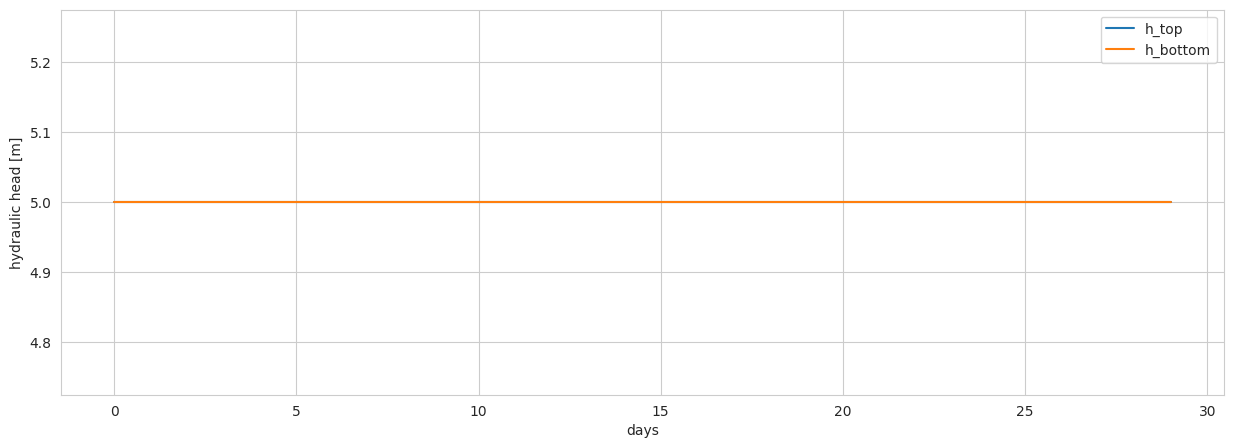

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Pre-calculate constants
two_pi = 2 * np.pi

# Linear temperature increase over time (0.3 degrees per day)
chg_per_day = 0.05

# Define a smooth square wave function using a sigmoid function
def smooth_square_wave(x, period):
    return 2 / (1 + np.exp(-5 * np.sin(two_pi * x / period))) - 1

# Reduce the frequency by increasing the period
reduced_period = 3 * seconds_per_week  # Double the period to reduce the frequency

# Calculate the top boundary using the smooth square wave function with reduced frequency
df_BC['h_top'] = ( 5 * smooth_square_wave(df_BC['times'], reduced_period) / 100  # Weekly fluctuation
                  + 5)  # Base temperature offset

# Set the bottom boundary to a constant value 
df_BC['h_top'] = 5 * np.ones_like(df_BC['times'])


# Set the bottom boundary to a constant value 
df_BC['h_bottom'] = 5 * np.ones_like(df_BC['times'])

# Plot the results
plt.figure(figsize=(15,5))
plt.plot(df_BC['days'], df_BC['h_top'], label='h_top')
plt.plot(df_BC['days'], df_BC['h_bottom'], label='h_bottom')
plt.xlabel('days')
plt.ylabel('hydraulic head [m]')
plt.legend()
plt.show()



## Boundary thermal conditions
We impose a time-varying surface temperature and a constant geothermal flux at the base.

For this example, the basal heat flux is fixed to $q_g = 0.065\,\mathrm{W/m^2}$. With $\lambda = 1.8\,\mathrm{W/(m\,^\circ C)}$, this corresponds to the geothermal gradient:

$$
\frac{dT}{dz} = \frac{q_g}{\lambda} = \frac{0.065}{1.8} \approx 0.0361\,\mathrm{^\circ C/m}
$$

That is about $3.61\,\mathrm{^\circ C}$ per $100\,\mathrm{m}$. This basal flux is then used for the lower Neumann thermal boundary condition and for the analytical initial temperature profile.

In [81]:
# Pre-calculate constants
two_pi = 2 * np.pi

# Linear temperature increase over time (0.3 degrees per day)
deg_per_day = 0.3

# Fixed basal heat flux
q_geo = 0.065
geothermal_gradient = q_geo / REF_l

# Calculate the top boundary temperature
df_BC['T_top'] = (5 * np.sin(two_pi * df_BC['times'] / seconds_per_day)  # Daily fluctuation
                  + deg_per_day * df_BC['days']  # Linear increase per day
                  + 3 * np.sin(two_pi * df_BC['times'] / seconds_per_week)  # Weekly fluctuation
                  + 17)  # Base temperature offset

# Set the bottom boundary geothermal flux to a constant value
df_BC['T_bottom'] = q_geo * np.ones_like(df_BC['times'])

print(f'Geothermal flux: {q_geo:.4f} W/m²')
print(f'Geothermal gradient: {geothermal_gradient:.4f} °C/m')

# Display the first few rows to check the results (optional)
print(df_BC.head())

Geothermal flux: 0.0650 W/m²
Geothermal gradient: 0.0361 °C/m
    times  days  h_top  h_bottom      T_top  T_bottom
0       0   0.0      5         5  17.000000     0.065
1   86400   1.0      5         5  19.645494     0.065
2  172800   2.0      5         5  20.524784     0.065
3  259200   3.0      5         5  19.201651     0.065
4  345600   4.0      5         5  16.898349     0.065


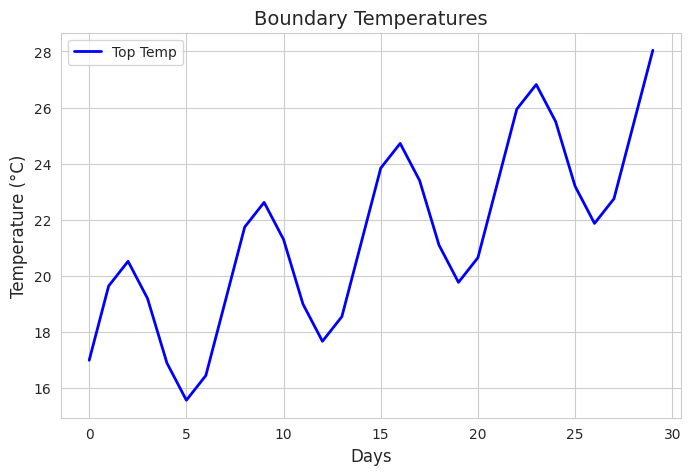

In [82]:
# Plot only the first 1000 points for quicker visualization
plt.figure(figsize=(8, 5))
plt.plot(df_BC['days'], df_BC['T_top'], label='Top Temp', color='b', lw=2)

plt.xlabel('Days', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('Boundary Temperatures', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)

plt.show()

In [83]:
# Create the obs_temp DataFrame
obs_temp = pd.DataFrame({
    'time': pd.to_timedelta(df_BC['times'], unit='s'),
    'h_top': df_BC['h_top'],
    'h_bottom': df_BC['h_bottom'],
    'T_top': df_BC['T_top'],
    'T_bottom': df_BC['T_bottom']
})

# Display the obs_temp DataFrame
print(obs_temp)

      time  h_top  h_bottom      T_top  T_bottom
0   0 days      5         5  17.000000     0.065
1   1 days      5         5  19.645494     0.065
2   2 days      5         5  20.524784     0.065
3   3 days      5         5  19.201651     0.065
4   4 days      5         5  16.898349     0.065
5   5 days      5         5  15.575216     0.065
6   6 days      5         5  16.454506     0.065
7   7 days      5         5  19.100000     0.065
8   8 days      5         5  21.745494     0.065
9   9 days      5         5  22.624784     0.065
10 10 days      5         5  21.301651     0.065
11 11 days      5         5  18.998349     0.065
12 12 days      5         5  17.675216     0.065
13 13 days      5         5  18.554506     0.065
14 14 days      5         5  21.200000     0.065
15 15 days      5         5  23.845494     0.065
16 16 days      5         5  24.724784     0.065
17 17 days      5         5  23.401651     0.065
18 18 days      5         5  21.098349     0.065
19 19 days      5   

## Initial temperatures
The initial temperature profile is built analytically from the surface temperature at $t=0$ and the basal geothermal flux:

$$
T(z,0) = T_s(0) - \frac{q_g}{\lambda} z
$$

with $z=0$ at the surface and $z<0$ downward. This gives a linear geothermal gradient that is consistent with the lower Neumann boundary condition.

Surface temperature at t=0: 17.00 °C
Geothermal flux: 0.065 W/m²
Geothermal gradient: 0.0361 °C/m
Temperature at z=0 m: 17.00 °C
Temperature expected at z=-100 m: 20.61 °C
Temperature of the last discretized point at z=-99 m: 20.57 °C


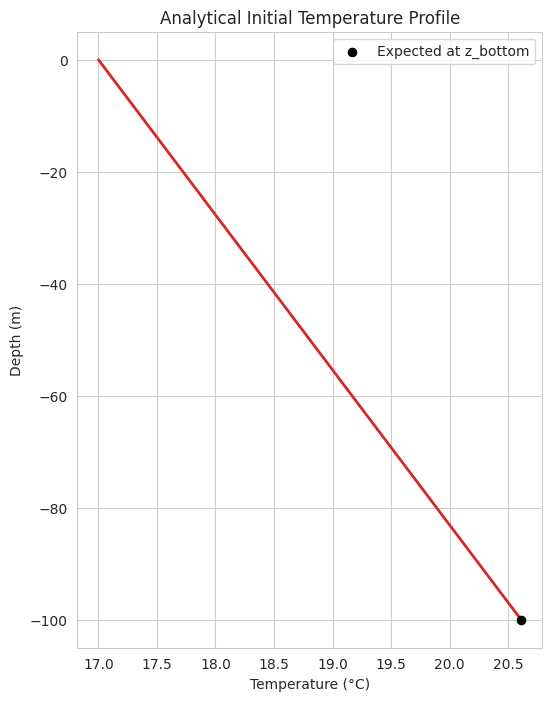

In [84]:
surface_temperature_t0 = float(obs_temp['T_top'].iloc[0])
q_geo = float(obs_temp['T_bottom'].iloc[0])

z_analytic = z_top - np.arange(n_depths) * dz
T_analytic_t0 = surface_temperature_t0 - (q_geo / REF_l) * z_analytic
T_bottom_expected = surface_temperature_t0 - (q_geo / REF_l) * z_bottom

analytic_profile_t0 = pd.DataFrame({
    'z': z_analytic,
    'T': T_analytic_t0,
}).sort_values(by='z', ascending=False)

plot_profile_t0 = pd.concat(
    [
        analytic_profile_t0,
        pd.DataFrame({'z': [z_bottom], 'T': [T_bottom_expected]})
    ],
    ignore_index=True,
).sort_values(by='z', ascending=False)

print(f'Surface temperature at t=0: {surface_temperature_t0:.2f} °C')
print(f'Geothermal flux: {q_geo:.3f} W/m²')
print(f'Geothermal gradient: {q_geo / REF_l:.4f} °C/m')
print(f'Temperature at z=0 m: {analytic_profile_t0.iloc[0]["T"]:.2f} °C')
print(f'Temperature expected at z={z_bottom:.0f} m: {T_bottom_expected:.2f} °C')
print(f'Temperature of the last discretized point at z={analytic_profile_t0.iloc[-1]["z"]:.0f} m: {analytic_profile_t0.iloc[-1]["T"]:.2f} °C')

plt.figure(figsize=(6, 8))
plt.plot(plot_profile_t0['T'], plot_profile_t0['z'], color='tab:red', lw=2)
plt.scatter([T_bottom_expected], [z_bottom], color='black', s=35, zorder=3, label='Expected at z_bottom')
plt.xlabel('Temperature (°C)')
plt.ylabel('Depth (m)')
plt.title('Analytical Initial Temperature Profile')
plt.grid(True)
plt.legend()
plt.show()

In [85]:
print("\nGenerating Ginette configuration files...")
prepare_ginette_directories(work_dir)
print(f'Working directory used by Ginette: {Path.cwd()}')
z_obs = setup_ginette_no_date(dt, state, nb_day, z_top, z_bottom, az, dz, dz_obs)


Generating Ginette configuration files...
Current working directory: /home/ariviere/Programmes/ginette/application/1D_Diffusive/SYNTHETIC_CASES
Directory 'SENSI' already exists.
Directory 'OUTPUT' already exists.
Working directory used by Ginette: /home/ariviere/Programmes/ginette/application/1D_Diffusive/SYNTHETIC_CASES


In [86]:
DM.initial_conditions(obs_temp, z_top, z_bottom, dz, z_obs)

temperature_initiale_path = Path(work_dir) / 'E_temperature_initiale.dat'
analytic_profile_t0['T'].to_csv(
    temperature_initiale_path,
    index=False,
    header=False,
    sep='\n',
    float_format='%.10f',
)

print(f'Analytical initial profile written to {temperature_initiale_path}')
print(f'{len(analytic_profile_t0)} temperatures saved, one per line.')

Analytical initial profile written to /home/ariviere/Programmes/ginette/application/1D_Diffusive/SYNTHETIC_CASES/E_temperature_initiale.dat
100 temperatures saved, one per line.


## Boundary conditions

In [87]:
DM.boundary_conditions(obs_temp,dt)

## run simulation

In [ ]:
sim_temp=DM.run_direct_model(z_bottom, dz, nb_zone, alt_thk, REF_k, REF_n, REF_l, REF_r, REF_k2=None, REF_n2=None, REF_l2=None, REF_r2=None) 

 simu done


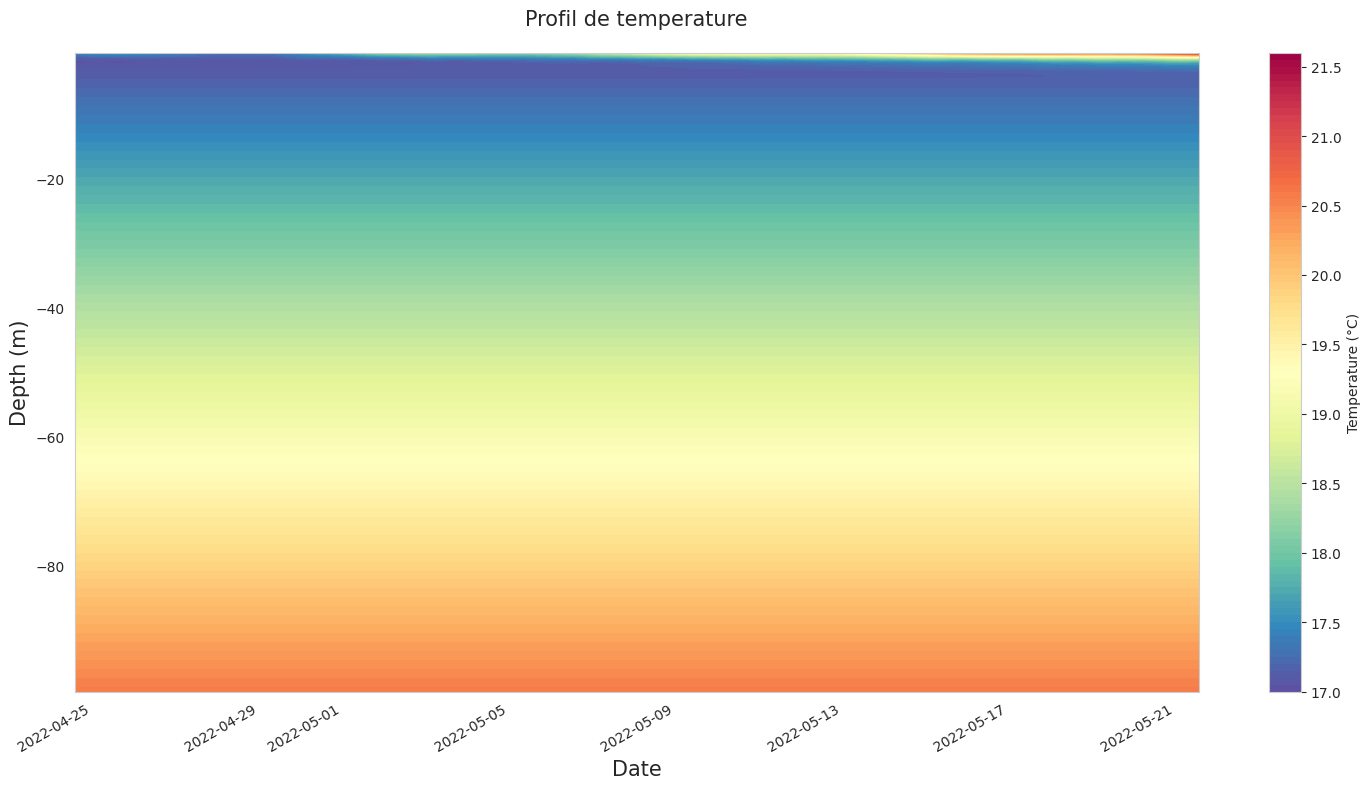

In [92]:
plot_temperature_profiles_interpol(date_simul_bg=pd.to_datetime("2022/04/21 14:00:00"))